# camelsch — Interactive Demo

This notebook demonstrates the camelsch Python API for working with the CAMELS-CH hydrological dataset (331 Swiss catchments, 1981–2020).

## 1. Download

The CAMELS-CH dataset is hosted on Zenodo (~250 MB). The `download` command fetches
and extracts it automatically. **If you have already downloaded, this is a no-op.**

In [1]:
import camelsch
from pathlib import Path

DATA_DIR = Path("data/CAMELS_CH")
camelsch.download_camels_ch(dest=DATA_DIR)
print(f"Dataset ready at: {DATA_DIR}")

Dataset ready at: data/CAMELS_CH


## 2. Dataset Overview

In [2]:
basins = camelsch.list_basins(DATA_DIR)
print(f"Basins: {len(basins)}")
print(f"First 10: {basins[:10]}")

variables = camelsch.list_variables(DATA_DIR)
print(f"\nVariables ({len(variables)}):")
for v in variables:
    print(f"  - {v}")

Basins: 331
First 10: ['2004', '2007', '2009', '2011', '2014', '2016', '2017', '2018', '2019', '2020']

Variables (21):
  - discharge_vol
  - discharge_spec
  - waterlevel
  - precipitation
  - temperature_min
  - temperature_mean
  - temperature_max
  - rel_sun_dur
  - swe
  - discharge_vol_sim
  - discharge_spec_sim
  - precipitation_sim
  - temperature_sim
  - radiation_sim
  - sun_duration_sim
  - wind_sim
  - rel_humidity_sim
  - pet_sim
  - et_sim
  - intercept_et_sim
  - intercept_storage_sim


## 3. Static Attributes

In [3]:
attrs = camelsch.load_attributes(DATA_DIR)
print(f"Shape: {attrs.shape}")
attrs.head()

Shape: (331, 300)


,ind_start_date,ind_end_date,ind_number_of_years,p_mean,pet_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,...,ext_srel,ext_sim,perc_jura,perc_black_forest,perc_plateau,perc_alps_north,perc_alps_west,perc_alps_south,perc_alps_east,bio_geo_dominant
gauge_id,,,,,,,,,,,,,,,,,,,,,
2004,1981-10-01,2020-09-30,39,3.059,1.827,0.597,0.159,0.039,19.487,1.169,...,99.77,99.77,0.0,0.0,96.38,3.62,0.00,0.0,0.0,plateau
2007,1981-10-01,2020-09-30,39,4.983,1.840,0.369,-0.118,0.170,18.282,1.213,...,100.00,100.00,100.0,0.0,0.00,0.00,0.00,0.0,0.0,Jura
2009,1981-10-01,2020-09-30,39,3.558,1.564,0.440,0.078,0.436,18.410,1.223,...,99.78,100.00,0.0,0.0,0.00,9.82,90.18,0.0,0.0,alps_west
2011,1981-10-01,2020-09-30,39,3.401,1.502,0.442,0.106,0.474,17.795,1.244,...,100.00,100.00,0.0,0.0,0.00,0.85,99.15,0.0,0.0,alps_west
2014,1981-10-01,2020-09-30,39,4.869,1.537,0.316,0.279,0.223,15.641,1.175,...,99.40,99.40,0.0,0.0,5.99,94.00,0.00,0.0,0.0,alps_north


In [4]:
# Filter to specific basins
subset = camelsch.load_attributes(DATA_DIR, basin_ids=["2004", "2007", "2034"])
subset[["gauge_name", "area", "elev_mean"]]

,gauge_name,area,elev_mean
gauge_id,,,
2004,Murten,712.7,644.60
2007,Le_Pont,209.3,1228.27
2034,Payerne-Caserne_d'aviation,415.9,723.40


In [5]:
# List all available attribute names
attr_names = camelsch.get_attribute_names(DATA_DIR)
print(f"Available attributes ({len(attr_names)}):")
for name in attr_names[:10]:
    print(f"  - {name}")
print(f"  ... and {len(attr_names) - 10} more")

Available attributes (300):
  - ind_start_date
  - ind_end_date
  - ind_number_of_years
  - p_mean
  - pet_mean
  - aridity
  - p_seasonality
  - frac_snow
  - high_prec_freq
  - high_prec_dur
  ... and 290 more


## 4. Time Series

In [6]:
# Load a single basin — obs + sim columns are merged automatically
ts = camelsch.load_basin_timeseries(DATA_DIR, "2004")
print(f"Shape: {ts.shape}")
print(f"Date range: {ts.index.min().date()} to {ts.index.max().date()}")
ts.head()

Shape: (14610, 23)
Date range: 1981-01-01 to 2020-12-31


,discharge_vol,discharge_spec,waterlevel,precipitation,temperature_min,temperature_mean,temperature_max,rel_sun_dur,swe,discharge_vol_sim,...,radiation_sim,sun_duration_sim,wind_sim,rel_humidity_sim,pet_sim,et_sim,intercept_et_sim,intercept_storage_sim,pet,et
date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,NaN,NaN,428.992,0.89,-1.63,2.02,3.68,0.84,NaN,8.661,...,20.78,0.25,1.92,0.75,0.27,0.27,0.24,1.19,0.27,0.27
1981-01-02,NaN,NaN,428.981,1.37,-0.78,0.77,2.76,0.08,NaN,9.073,...,19.52,0.00,2.07,0.86,0.09,0.09,0.08,1.29,0.09,0.09
1981-01-03,NaN,NaN,428.995,18.46,1.92,4.03,5.54,0.34,NaN,22.105,...,19.64,0.07,3.49,0.83,0.35,0.35,0.32,1.32,0.35,0.35
1981-01-04,NaN,NaN,429.085,12.81,-0.96,3.19,5.73,0.35,NaN,68.791,...,15.39,0.21,2.40,0.86,0.09,0.09,0.07,1.33,0.09,0.09
1981-01-05,NaN,NaN,429.191,2.87,-2.46,-1.03,0.40,8.84,NaN,63.512,...,38.82,1.11,1.84,0.76,0.20,0.20,0.17,1.28,0.20,0.20


In [7]:
# Load multiple basins with variable and date filtering
data = camelsch.load_timeseries(
    DATA_DIR,
    basin_ids=["2004", "2007"],
    variables=["precipitation", "discharge_spec"],
    start_date="2000-01-01",
    end_date="2000-01-10",
)
for bid, df in data.items():
    print(f"\nBasin {bid}:")
    print(df)


Basin 2004:
            precipitation  discharge_spec
date                                     
2000-01-01           0.05             NaN
2000-01-02           0.00             NaN
2000-01-03           0.08             NaN
2000-01-04           1.32             NaN
2000-01-05           0.06             NaN
2000-01-06           0.01             NaN
2000-01-07           0.00             NaN
2000-01-08           0.00             NaN
2000-01-09           0.73             NaN
2000-01-10           0.31             NaN

Basin 2007:
            precipitation  discharge_spec
date                                     
2000-01-01           0.09             NaN
2000-01-02           0.00             NaN
2000-01-03           0.00             NaN
2000-01-04           4.31             NaN
2000-01-05           0.18             NaN
2000-01-06           0.00             NaN
2000-01-07           0.00             NaN
2000-01-08           0.01             NaN
2000-01-09           3.06             NaN
2000-01-

In [8]:
# pet and et are convenience aliases for pet_sim and et_sim
ts = camelsch.load_basin_timeseries(DATA_DIR, "2004")
print("pet alias present:", "pet" in ts.columns)
print("et alias present:", "et" in ts.columns)
print(f"\npet == pet_sim: {(ts['pet'] == ts['pet_sim']).all()}")
print(f"et == et_sim: {(ts['et'] == ts['et_sim']).all()}")

pet alias present: True
et alias present: True

pet == pet_sim: True
et == et_sim: True


### Annual resampling

`resample_annual()` aggregates daily data to annual resolution. Precipitation,
discharge, and SWE columns are **summed**; temperature, radiation, humidity, and
other variables are **averaged**.

In [9]:
annual = camelsch.resample_annual(ts)
print(f"Daily shape: {ts.shape}")
print(f"Annual shape: {annual.shape}")
annual.head()

Daily shape: (14610, 23)
Annual shape: (40, 23)


,discharge_vol,discharge_spec,waterlevel,precipitation,temperature_min,temperature_mean,temperature_max,rel_sun_dur,swe,discharge_vol_sim,...,radiation_sim,sun_duration_sim,wind_sim,rel_humidity_sim,pet_sim,et_sim,intercept_et_sim,intercept_storage_sim,pet,et
date,,,,,,,,,,,,,,,,,,,,,
1981-12-31,0.0,0.0,429.309342,1255.46,4.130466,8.306219,12.586164,34.035589,0.0,6975.487,...,130.828411,3.982438,1.261096,0.757260,1.536712,1.430247,202.98,366.18,1.536712,1.430247
1982-12-31,0.0,0.0,429.327507,1282.03,5.076329,9.060110,13.397616,35.089699,0.0,6663.951,...,136.729288,4.341041,1.282055,0.748986,1.700904,1.560849,211.87,343.35,1.700904,1.560849
1983-12-31,0.0,0.0,429.351611,1157.55,4.822630,8.851890,13.314548,35.309863,0.0,6050.112,...,131.522329,4.334247,1.364384,0.749452,1.727562,0.000000,209.67,332.72,1.727562,0.000000
1984-12-31,0.0,0.0,429.313765,1153.88,4.091858,8.056913,12.311120,36.849044,0.0,5856.024,...,130.637131,4.505902,1.408251,0.746858,1.573033,1.371858,186.37,354.01,1.573033,1.371858
1985-12-31,0.0,0.0,429.269600,1109.30,3.607342,7.916411,12.548082,41.367452,0.0,5418.870,...,139.125808,5.011014,1.280055,0.741397,1.658493,1.487014,194.85,330.83,1.658493,1.487014


## 5. Catchment Geometries

In [10]:
gdf = camelsch.load_geometries(DATA_DIR)
print(f"CRS: {gdf.crs}")
print(f"Basins: {len(gdf)}")
gdf.head()

CRS: EPSG:2056
Basins: 331


,ID6,gauge_name,water_body,type,country,Shape_Leng,Shape_Area,ORIG_FID,geometry
gauge_id,,,,,,,,,
2004.0,MuSMur,Murten,Murtensee,lake,CH,218617.225557,7.126515e+08,0,"POLYGON Z ((2574447.038 1201567.37 0, 2574462...."
2007.0,LdJLeP,Le_Pont,Lac_de_Joux,lake,CH,90418.652034,2.092525e+08,1,"POLYGON Z ((2516559.612 1169820.678 0, 2516557..."
2009.0,RhoPor,Porte_du_Scex,Rhône,stream,CH,581812.194190,5.239402e+09,2,"POLYGON Z ((2674253.038 1167429.881 0, 2674340..."
2011.0,RhoSio,Sion,Rhône,stream,CH,373714.667313,3.372417e+09,3,"POLYGON Z ((2674253.038 1167429.881 0, 2674340..."
2014.0,ZuSSch,Schmerikon,Zürichsee_(Obersee),lake,CH,244190.991589,1.583453e+09,4,"POLYGON Z ((2710186.071 1241459.749 0, 2710196..."


In [11]:
# Reproject to WGS 84
gdf_wgs84 = camelsch.load_geometries(DATA_DIR, crs="EPSG:4326")
print(f"Reprojected CRS: {gdf_wgs84.crs}")
gdf_wgs84.head(3)

Reprojected CRS: EPSG:4326


,ID6,gauge_name,water_body,type,country,Shape_Leng,Shape_Area,ORIG_FID,geometry
gauge_id,,,,,,,,,
2004.0,MuSMur,Murten,Murtensee,lake,CH,218617.225557,7.126515e+08,0,"POLYGON Z ((7.10288 46.96469 0, 7.10308 46.964..."
2007.0,LdJLeP,Le_Pont,Lac_de_Joux,lake,CH,90418.652034,2.092525e+08,1,"POLYGON Z ((6.34814 46.67438 0, 6.34811 46.674..."
2009.0,RhoPor,Porte_du_Scex,Rhône,stream,CH,581812.194190,5.239402e+09,2,"POLYGON Z ((8.40869 46.65398 0, 8.40983 46.653..."


In [12]:
# Filter to specific basins
gdf_subset = camelsch.load_geometries(DATA_DIR, basin_ids=["2004", "2007"])
print(f"Filtered to {len(gdf_subset)} basins")

Filtered to 0 basins


## 6. Visualization

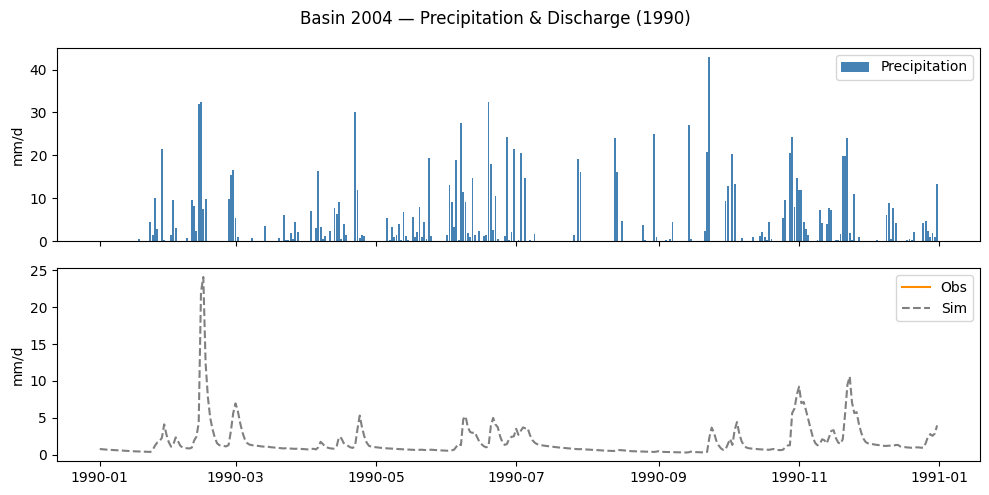

In [13]:
import matplotlib.pyplot as plt

ts = camelsch.load_basin_timeseries(DATA_DIR, "2004")

# Plot one year of data for clarity
ts_year = ts.loc["1990"]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].bar(ts_year.index, ts_year["precipitation"], color="steelblue", label="Precipitation")
axes[0].set_ylabel("mm/d")
axes[0].legend()

axes[1].plot(ts_year.index, ts_year["discharge_spec"], color="darkorange", label="Obs")
axes[1].plot(ts_year.index, ts_year["discharge_spec_sim"], color="grey", linestyle="--", label="Sim")
axes[1].set_ylabel("mm/d")
axes[1].legend()

fig.suptitle("Basin 2004 — Precipitation & Discharge (1990)")
plt.tight_layout()
plt.show()

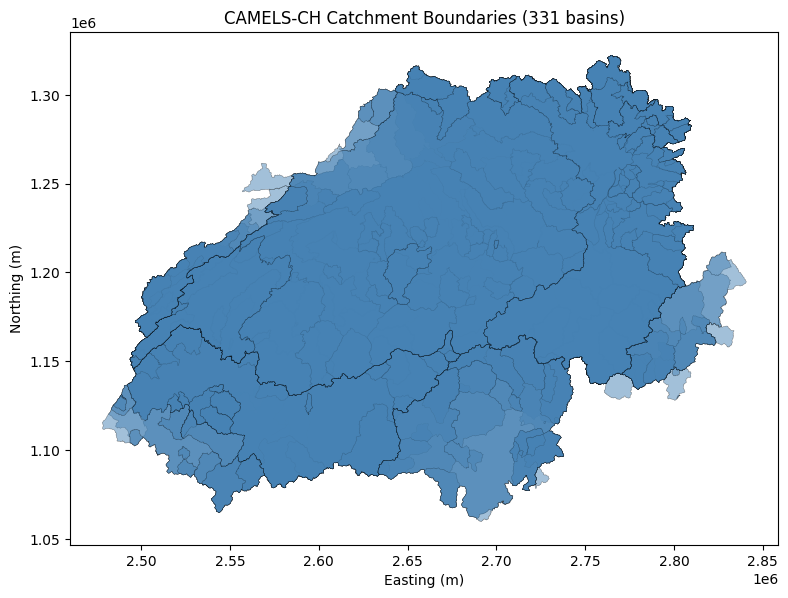

In [14]:
gdf = camelsch.load_geometries(DATA_DIR)

fig, ax = plt.subplots(figsize=(8, 6))
gdf.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5, linewidth=0.3)
ax.set_title("CAMELS-CH Catchment Boundaries (331 basins)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Export

In [15]:
import tempfile
import pandas as pd

with tempfile.TemporaryDirectory() as tmp:
    # Timeseries CSV
    ts = camelsch.load_basin_timeseries(DATA_DIR, "2004")
    out = Path(tmp) / "basin_2004.csv"
    camelsch.export_timeseries({"2004": ts}, out, fmt="csv")
    print(f"Timeseries CSV: {out.stat().st_size:,} bytes")

    # Timeseries Parquet (multiple basins)
    data = camelsch.load_timeseries(DATA_DIR, basin_ids=["2004", "2007", "2034"])
    out = Path(tmp) / "timeseries.parquet"
    camelsch.export_timeseries(data, out, fmt="parquet")
    print(f"Timeseries Parquet: {out.stat().st_size:,} bytes")

    # Attributes CSV
    attrs = camelsch.load_attributes(DATA_DIR)
    out = Path(tmp) / "attributes.csv"
    camelsch.export_attributes(attrs, out, fmt="csv")
    print(f"Attributes CSV: {out.stat().st_size:,} bytes")

    # Merged timeseries + attributes
    out = Path(tmp) / "merged.parquet"
    camelsch.export_merged(data, attrs, out, fmt="parquet")
    readback = pd.read_parquet(out)
    print(f"Merged Parquet: {out.stat().st_size:,} bytes (shape: {readback.shape})")

    # Geometry export
    gdf = camelsch.load_geometries(DATA_DIR)
    out = Path(tmp) / "catchments.gpkg"
    camelsch.export_geometries(gdf, out, fmt="gpkg")
    print(f"GeoPackage: {out.stat().st_size:,} bytes")

    out = Path(tmp) / "catchments.geojson"
    camelsch.export_geometries(gdf, out, fmt="geojson")
    print(f"GeoJSON: {out.stat().st_size:,} bytes")

Timeseries CSV: 1,788,044 bytes
Timeseries Parquet: 1,837,440 bytes
Attributes CSV: 584,419 bytes


/Users/bea/camelsch/src/camelsch/export.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = attributes.loc[bid, col]
/Users/bea/camelsch/src/camelsch/export.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col] = attributes.loc[bid, col]
/Users/bea/camelsch/src/camelsch/export.py:87: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fr

Merged Parquet: 2,073,467 bytes (shape: (43830, 324))
GeoPackage: 76,603,392 bytes
GeoJSON: 182,764,263 bytes


## 8. CLI Demo

All functionality is also available via the `camelsch` CLI.

In [16]:
!camelsch --version

camelsch 0.2.0


In [17]:
!camelsch info

                           CAMELS-CH Dataset Summary                            
┌────────────┬─────────────────────────────────────────────────────────────────┐
│ Location   │ data/CAMELS_CH                                                  │
│ Basins     │ 331                                                             │
│ Time range │ 1981-01-01 to 2020-12-31                                        │
│ Variables  │ discharge_vol, discharge_spec, waterlevel, precipitation,       │
│            │ temperature_min, temperature_mean, temperature_max,             │
│            │ rel_sun_dur, swe, discharge_vol_sim, discharge_spec_sim,        │
│            │ precipitation_sim, temperature_sim, radiation_sim,              │
│            │ sun_duration_sim, wind_sim, rel_humidity_sim, pet_sim, et_sim,  │
│            │ intercept_et_sim, intercept_storage_sim                         │
│ Attributes │ 300 static features                                             │
│ Geometry   │ Available (LV

In [18]:
!camelsch basins --format json | head -20

[
  "2004",
  "2007",
  "2009",
  "2011",
  "2014",
  "2016",
  "2017",
  "2018",
  "2019",
  "2020",
  "2021",
  "2022",
  "2023",
  "2024",
  "2025",
  "2026",
  "2027",
  "2028",
  "2029",


In [19]:
!camelsch attributes --basins 2004,2007

gauge_id,ind_start_date,ind_end_date,ind_number_of_years,p_mean,pet_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,high_prec_timing,low_prec_freq,low_prec_dur,low_prec_timing,geo_porosity,geo_log10_permeability,unconsol_sediments,siliciclastic_sedimentary,mixed_sedimentary,carbonate_sedimentary,pyroclastic,acid_volcanic,basic_volcanic,acid_plutonic,intermediate_plutonic,basic_plutonic,metamorphics,water_geo,ice_geo,glac_area,glac_vol,glac_mass,glac_area_neighbours,n_inhabitants,dens_inhabitants,hp_count,hp_qturb,hp_inst_turb,hp_max_power,num_reservoir,reservoir_cap,reservoir_he,reservoir_fs,reservoir_irr,reservoir_nousedata,reservoir_year_first,reservoir_year_last,unconsol_coarse_perc,unconsol_medium_perc,unconsol_fine_perc,unconsol_imperm_perc,hardrock_perc,hardrock_imperm_perc,karst_perc,water_perc,null_perc,ext_area_perc,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,h

In [20]:
!camelsch timeseries --basins 2004 --vars precipitation,discharge_spec --start 2000-01-01 --end 2000-01-10

date,precipitation,discharge_spec
2000-01-01,0.05,
2000-01-02,0.0,
2000-01-03,0.08,
2000-01-04,1.32,
2000-01-05,0.06,
2000-01-06,0.01,
2000-01-07,0.0,
2000-01-08,0.0,
2000-01-09,0.73,
2000-01-10,0.31,


In [21]:
!camelsch timeseries --basins 2004 --resolution annual | head -5

date,discharge_vol,discharge_spec,waterlevel,precipitation,temperature_min,temperature_mean,temperature_max,rel_sun_dur,swe,discharge_vol_sim,discharge_spec_sim,precipitation_sim,temperature_sim,radiation_sim,sun_duration_sim,wind_sim,rel_humidity_sim,pet_sim,et_sim,intercept_et_sim,intercept_storage_sim,pet,et
1981-12-31,0.0,0.0,429.30934246575345,1255.46,4.130465753424657,8.306219178082191,12.586164383561643,34.03558904109589,0.0,6975.487,845.6899999999999,1366.93,8.425260273972603,130.82841095890413,3.9824383561643835,1.261095890410959,0.7572602739726026,1.5367123287671232,1.4302465753424656,202.98,366.18,1.5367123287671232,1.4302465753424656
1982-12-31,0.0,0.0,429.3275068493151,1282.03,5.076328767123288,9.060109589041096,13.397616438356165,35.089698630136986,0.0,6663.951,807.92,1337.03,9.24241095890411,136.7292876712329,4.341041095890411,1.2820547945205478,0.748986301369863,1.7009041095890411,1.5608493150684932,211.87,343.35,1.7009041095890411,1.5608493150684932
1983-12-31,0.0,0.0,